In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path = "./data/project_dataset.csv"

In [2]:
path = "./data/project_dataset.csv"
df = pd.read_csv(path, sep=";")

df = df.drop_duplicates()
df = df.fillna(0.00 )

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
df.to_csv("cleared_dataset.csv", index=False)
df.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,0.0,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,0.0,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,0.0,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,0.0,71.0,7.235211268,...,39.0,5.292211221,18.0,0.0,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,0.0,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,0.0,15.78947368,1.754385965,1.754385965


## Start Step 2

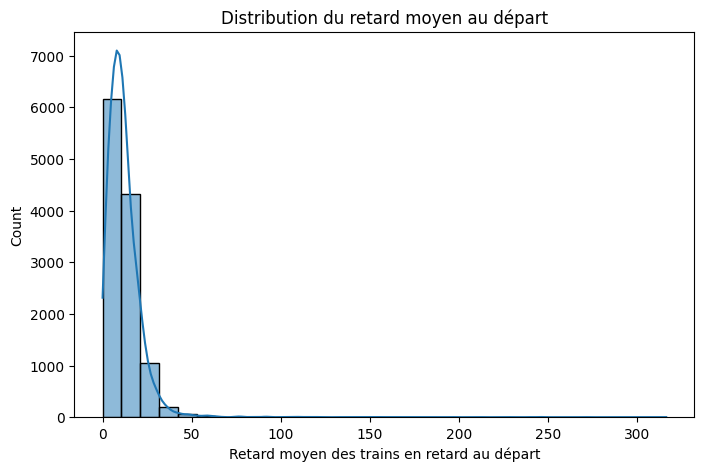

In [3]:
# Statistiques générales
# df.describe()


delay_cols = [
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ",
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min",
]

df[delay_cols].describe()


cols_to_convert = [
    "Retard moyen des trains en retard au départ",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
]

for col in cols_to_convert:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

plt.figure(figsize=(8, 5))
sns.histplot(df["Retard moyen des trains en retard au départ"], bins=30, kde=True)
plt.title("Distribution du retard moyen au départ")
plt.show()

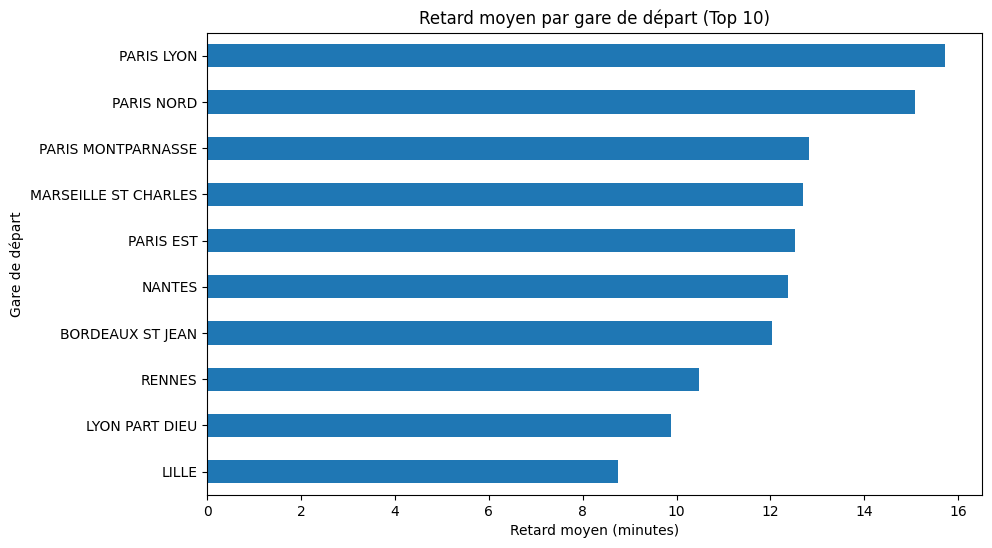

In [4]:
top_stations = df["Gare de départ"].value_counts().head(10).index

station_delay = (
    df[df["Gare de départ"].isin(top_stations)]
    .groupby("Gare de départ")["Retard moyen des trains en retard au départ"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
station_delay.plot(kind="barh")
plt.title("Retard moyen par gare de départ (Top 10)")
plt.xlabel("Retard moyen (minutes)")
plt.show()